# Large-scale learning: partial_fit and hashing

From the large-scale ML colab. Up to now every dataset fitted in memory and `fit()` saw all of it at once.
When the data doesn't fit, or keeps arriving over time, the model has to learn from it a batch at a time.

1. incremental (out-of-core) learning and `partial_fit`
2. `fit()` vs `partial_fit()` on the same data, reading a CSV in chunks
3. why one pass of `partial_fit` scores lower, and how to close the gap
4. `CountVectorizer` vs `HashingVectorizer`
5. streaming text: `HashingVectorizer` + `SGDClassifier` on SMS spam
6. which estimators support `partial_fit`

## Incremental learning

Two situations where it's needed:

* **the data doesn't fit in RAM.** Load it in chunks and update the model on each chunk.
* **new data keeps arriving.** Retraining from scratch on old + new data every time is expensive. Updating
  the existing model with the new batch is much cheaper.

In scikit-learn this is the `partial_fit` method:

```python
partial_fit(X, y, classes=None, sample_weight=None)
```

* `X`, `y`: one batch of samples
* `classes`: every class label that can ever appear. Required on the **first** call for classifiers, since the
  first batch might not contain all of them. Can be left out afterwards.
* `sample_weight`: optional per-sample weights

Each call does a single pass over the batch it's given. There's some overhead per call, so batches should be
reasonably large (whatever comfortably fits in memory), not one row at a time.

`SGDClassifier` and `SGDRegressor` are the usual choice: stochastic gradient descent only ever looks at a few
samples at a time anyway, so it doesn't need the whole dataset in memory. Batch methods like SVMs with kernels
or random forests do.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

## fit() vs partial_fit()

A synthetic 3-class problem: 50,000 samples, 10 features, one cluster per class. The original colab had no
random seeds, so its numbers changed on every run; seeds are fixed here.

In [2]:
X, y = make_classification(n_samples=50000, n_features=10, n_classes=3, n_clusters_per_class=1,
                           random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, np.bincount(y_train))

(42500, 10) (7500, 10) [14173 14175 14152]


### 1. Everything at once with fit()

In [3]:
clf_fit = SGDClassifier(random_state=42)
clf_fit.fit(X_train, y_train)

print(f"train accuracy: {clf_fit.score(X_train, y_train):.3f}")
print(f"test accuracy:  {clf_fit.score(X_test, y_test):.3f}")
print(f"epochs run:     {clf_fit.n_iter_}")

train accuracy: 0.920
test accuracy:  0.918
epochs run:     32


              precision    recall  f1-score   support

           0      0.989     0.812     0.892      2501
           1      0.842     0.962     0.898      2501
           2      0.946     0.980     0.962      2498

    accuracy                          0.918      7500
   macro avg      0.925     0.918     0.917      7500
weighted avg      0.925     0.918     0.917      7500



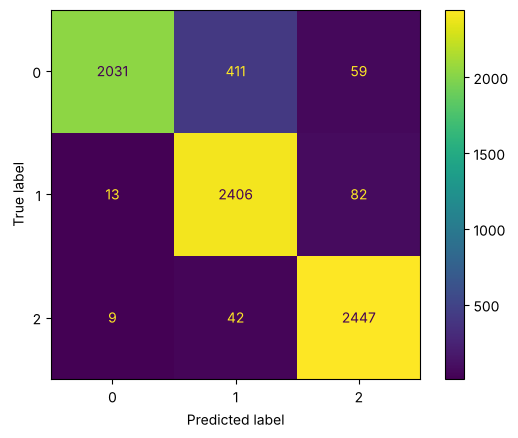

In [4]:
y_pred = clf_fit.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

### 2. In chunks with partial_fit()

Pretend the training set is too big for memory. To simulate that, write it to a CSV first (features plus the
label as the last column) and then read it back 1,000 rows at a time with `read_csv(..., chunksize=...)`.
Only one chunk is in memory at any point.

In [5]:
np.savetxt("train_data.csv", np.column_stack([X_train, y_train]), delimiter=",")
print(os.path.getsize("train_data.csv") / 1e6, "MB")

11.89337 MB


`np.savetxt` doesn't write a header row, so `header=None` is needed when reading it back. The course colab
left it out, and pandas then used the first sample as column names: one training row silently lost, and
column "names" like `-0.687...`.

In [6]:
clf_inc = SGDClassifier(random_state=42)
classes = np.unique(y)          # must be passed on the first call
chunk_acc = []

for i, chunk in enumerate(pd.read_csv("train_data.csv", header=None, chunksize=1000)):
    X_chunk = chunk.iloc[:, :-1].to_numpy()
    y_chunk = chunk.iloc[:, -1].astype(int).to_numpy()
    if i == 0:
        clf_inc.partial_fit(X_chunk, y_chunk, classes=classes)
    else:
        clf_inc.partial_fit(X_chunk, y_chunk)
    chunk_acc.append(clf_inc.score(X_test, y_test))

print("chunks:", len(chunk_acc))
print(f"test accuracy after one pass: {chunk_acc[-1]:.3f}")

chunks: 43
test accuracy after one pass: 0.899


Converting each chunk with `.to_numpy()` avoids the "X does not have valid feature names" warnings the
original run printed: the model was trained on DataFrames (with column names) and then scored on a plain
array.

The colab printed `coef_` after every chunk to show the weights changing. Test accuracy after each chunk is
easier to read:

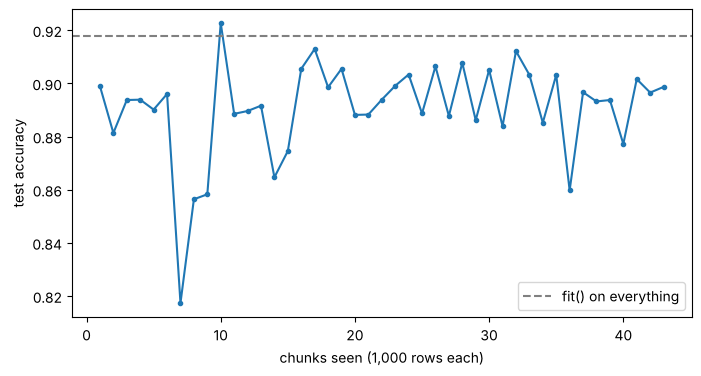

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(chunk_acc) + 1), chunk_acc, marker='.')
plt.axhline(clf_fit.score(X_test, y_test), color='gray', ls='--', label='fit() on everything')
plt.xlabel('chunks seen (1,000 rows each)')
plt.ylabel('test accuracy')
plt.legend()
plt.show()

In [8]:
y_pred_inc = clf_inc.predict(X_test)
print(classification_report(y_test, y_pred_inc, digits=3))

              precision    recall  f1-score   support

           0      0.973     0.766     0.857      2501
           1      0.838     0.954     0.892      2501
           2      0.909     0.976     0.941      2498

    accuracy                          0.899      7500
   macro avg      0.906     0.899     0.897      7500
weighted avg      0.906     0.899     0.897      7500



### Why is one pass worse?

0.899 after one pass vs 0.918 from `fit()`. (The course run, without seeds, had 0.82 vs 0.87; same pattern.)

`fit()` and `partial_fit()` aren't doing the same amount of work:

* `fit()` makes **several passes** (epochs) over the data, reshuffling each time, until the loss stops
  improving (`n_iter_` above). `max_iter` and `tol` only apply to `fit()`; `partial_fit` ignores them.
* `partial_fit()` does exactly **one pass** over each batch it's given. Reading the file once = one epoch.
* the CSV is read in the same order every time, with no shuffling across chunks.

So reading the file several times should close most of the gap. Each pass over the file is one epoch:

In [9]:
def train_epochs(n_epochs, scaler=None, seed=42):
    clf = SGDClassifier(random_state=seed)
    acc = []
    for epoch in range(n_epochs):
        for chunk in pd.read_csv("train_data.csv", header=None, chunksize=1000):
            Xc = chunk.iloc[:, :-1].to_numpy()
            yc = chunk.iloc[:, -1].astype(int).to_numpy()
            if scaler is not None:
                Xc = scaler.transform(Xc)
            clf.partial_fit(Xc, yc, classes=classes)
        Xt = X_test if scaler is None else scaler.transform(X_test)
        acc.append(clf.score(Xt, y_test))
    return clf, acc

clf_multi, epoch_acc = train_epochs(10)
for e, a in enumerate(epoch_acc, 1):
    print(f"epoch {e:2d}: {a:.3f}")

epoch  1: 0.899
epoch  2: 0.922
epoch  3: 0.921
epoch  4: 0.924
epoch  5: 0.924
epoch  6: 0.927
epoch  7: 0.924
epoch  8: 0.924
epoch  9: 0.922
epoch 10: 0.922


(Passing `classes` on every call is fine; it only has to be there on the first one.)

### Scaling incrementally

SGD is sensitive to feature scale, so in practice the data should be standardised. `StandardScaler` also has
`partial_fit`: it updates its running mean and variance chunk by chunk. That takes one extra pass over the file
before training starts.

In [10]:
scaler = StandardScaler()
for chunk in pd.read_csv("train_data.csv", header=None, chunksize=1000):
    scaler.partial_fit(chunk.iloc[:, :-1].to_numpy())

full = StandardScaler().fit(X_train)
print("same mean as fitting on everything:", np.allclose(scaler.mean_, full.mean_))
print("same std as fitting on everything: ", np.allclose(scaler.scale_, full.scale_))

clf_scaled, scaled_acc = train_epochs(10, scaler=scaler)
print("test accuracy per pass, scaled:", np.round(scaled_acc, 3))

same mean as fitting on everything: True
same std as fitting on everything:  True


test accuracy per pass, scaled: [0.942 0.924 0.927 0.935 0.934 0.933 0.935 0.932 0.933 0.933]


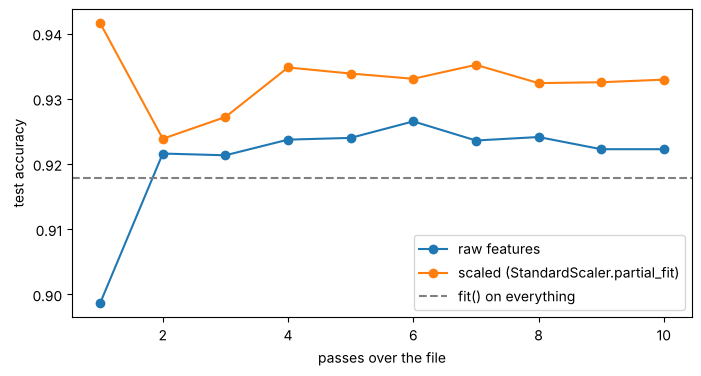

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), epoch_acc, marker='o', label='raw features')
plt.plot(range(1, 11), scaled_acc, marker='o', label='scaled (StandardScaler.partial_fit)')
plt.axhline(clf_fit.score(X_test, y_test), color='gray', ls='--', label='fit() on everything')
plt.xlabel('passes over the file')
plt.ylabel('test accuracy')
plt.legend()
plt.show()

* raw features: one pass gets 0.899, and from the second pass on it's at or slightly above the `fit()` result
  (0.92 to 0.93). It doesn't keep improving after that; SGD just bounces around the optimum.
* scaled features: better from the first pass (0.94) and settles around 0.933, above everything unscaled.
  `make_classification` features are already roughly unit scale, so the effect is modest here. On real data
  with columns in very different units it's usually much bigger.

The scaler needs the extra pass because it has to know the mean and standard deviation before the first
chunk is transformed. Fitting the scaler on each chunk separately would scale every chunk differently.

Clean up the file:

In [12]:
os.remove("train_data.csv")

Apart from `SGDClassifier`, `Perceptron`, `MultinomialNB` and `BernoulliNB` can be trained the same way.

## CountVectorizer vs HashingVectorizer

Text is the classic large-scale case: millions of documents, and a vocabulary that keeps growing.
`CountVectorizer` has two problems there:

* it stores the whole vocabulary (`vocabulary_`), which can be huge
* the vocabulary is learned in `fit`. A new chunk with new words would need a refit, which changes the
  number of columns, and the model's weights no longer line up

`HashingVectorizer` stores nothing. Each token is put through a hash function, and the hash (mod
`n_features`) decides its column. The output always has `n_features` columns, no matter what words turn up,
so every batch has the same shape. There's nothing to fit, so it works the same on every chunk.

Four short documents about apples:

In [13]:
from sklearn.feature_extraction.text import CountVectorizer, HashingVectorizer

text_documents = [
    'The well-known saying an apple a day keeps the doctor away has a very straightforward, literal meaning, '
    'that the eating of fruit maintains good health.',
    'The proverb first appeared in print in 1866 and over 150 years later is advice that we still pass down '
    'through generations.',
    'British apples are one of the nations best loved fruit and according to Great British Apples, we consume '
    'around 122,000 tonnes of them each year.',
    'But what are the health benefits, and do they really keep the doctor away?',
]

### CountVectorizer

In [14]:
c_vectorizer = CountVectorizer()
X_c = c_vectorizer.fit_transform(text_documents)
print(X_c.shape)
print(list(c_vectorizer.vocabulary_.items())[:10])

(4, 66)
[('the', 54), ('well', 62), ('known', 36), ('saying', 50), ('an', 6), ('apple', 9), ('day', 19), ('keeps', 35), ('doctor', 21), ('away', 13)]


66 distinct words, so 66 columns, and the vectoriser carries a dictionary from word to column. Counts for
the first document:

In [15]:
pd.Series(X_c[0].toarray()[0], index=c_vectorizer.get_feature_names_out()).loc[lambda s: s > 0] \
    .sort_values(ascending=False).head(10)

the       3
an        1
away      1
day       1
doctor    1
apple     1
eating    1
fruit     1
has       1
good      1
dtype: int64

### HashingVectorizer

`n_features` sets the number of columns. Here it's deliberately small (50, fewer than the 66 words) to show
what happens:

In [16]:
h_vectorizer = HashingVectorizer(n_features=50)
X_h = h_vectorizer.transform(text_documents)     # fit does nothing, there's no state
print(X_h.shape)
print(X_h[0])

(4, 50)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (1, 50)>
  Coords	Values
  (0, 5)	0.0
  (0, 8)	-0.47140452079103173
  (0, 10)	-0.23570226039551587
  (0, 11)	-0.23570226039551587
  (0, 13)	0.0
  (0, 18)	-0.23570226039551587
  (0, 20)	0.23570226039551587
  (0, 26)	0.0
  (0, 29)	0.23570226039551587
  (0, 33)	0.23570226039551587
  (0, 36)	-0.23570226039551587
  (0, 38)	0.47140452079103173
  (0, 39)	-0.23570226039551587
  (0, 45)	-0.23570226039551587
  (0, 46)	0.23570226039551587


A few things look odd compared to counts:

* **negative values.** `alternate_sign=True` (the default) gives each word a sign from a second hash. When
  two words land in the same column they partly cancel instead of always adding up, which keeps the
  collision error unbiased on average.
* **values like 0.2357.** The rows are L2-normalised by default (`norm='l2'`).
* some entries are exactly **0.0** but still stored: two words with opposite signs collided and cancelled.

### Collisions

With 66 words and 50 columns, collisions are guaranteed. Hashing each vocabulary word on its own shows
which ones share a column:

In [17]:
vocab = c_vectorizer.get_feature_names_out()
cols = h_vectorizer.transform(vocab).tocsr()
word_col = pd.Series([cols[i].indices[0] for i in range(len(vocab))], index=vocab)

shared = word_col.groupby(word_col).filter(lambda g: len(g) > 1)
print(f"{word_col.nunique()} columns used for {len(vocab)} words")
print(shared.groupby(shared).apply(lambda g: ', '.join(g.index)).head(12).to_string())

35 columns used for 66 words
5     health, literal, tonnes
8                 saying, the
9         british, each, what
11               an, do, over
12       according, but, year
13         1866, doctor, well
24               consume, one
26              meaning, very
27                 around, is
29                 good, they
33              fruit, really
36         are, eating, first


The model can't tell these words apart. With a realistic setting (the default is $2^{20}$ = 1,048,576
columns) collisions are rare, and the matrix is sparse so the large width costs nothing:

In [18]:
for n in [50, 2**10, 2**20]:
    cols = HashingVectorizer(n_features=n).transform(vocab).tocsr()
    used = len({cols[i].indices[0] for i in range(len(vocab))})
    print(f"n_features={n:>9,}: {len(vocab) - used} words lost to collisions")

n_features=       50: 31 words lost to collisions
n_features=    1,024: 3 words lost to collisions
n_features=1,048,576: 0 words lost to collisions


The price: no `get_feature_names_out()` and no way back from a column to a word, so you can't inspect which
words the model relies on. Use `CountVectorizer` / `TfidfVectorizer` when the data fits and you want to see
the vocabulary; `HashingVectorizer` when it doesn't, or when you're learning incrementally.

## Streaming text: HashingVectorizer + SGDClassifier

The course used 1,000 Amazon phone reviews (UCI's *sentiment labelled sentences*), split in two halves of
400 and 399. The SMS spam data from notebook 19 is used here instead: 5,572 messages gives enough batches
for the learning curve to mean something.

In [19]:
import io, urllib.request, zipfile

if not os.path.exists('SMSSpamCollection'):
    url = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'
    with zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read())) as z:
        z.extract('SMSSpamCollection')

sms = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'text'])
sms['spam'] = (sms['label'] == 'spam').astype(int)

X_train, X_test, y_train, y_test = train_test_split(sms['text'], sms['spam'], test_size=0.2,
                                                    random_state=42, stratify=sms['spam'])
print(len(X_train), "train,", len(X_test), "test,", f"{y_train.mean():.1%} spam")

4457 train, 1115 test, 13.4% spam


`alternate_sign=False` keeps all values non-negative (needed if you later want to swap in `MultinomialNB`, and
it doesn't hurt here). The test set is hashed once; since the vectoriser has no state, the training batches
can be hashed one at a time as they arrive.

The messages are fed in as a stream of batches of 500, and the model is scored after each one. F1 on the
spam class rather than accuracy, since only 13% is spam.

In [20]:
from sklearn.metrics import f1_score

vectorizer = HashingVectorizer(n_features=2**18, alternate_sign=False)
X_test_hashed = vectorizer.transform(X_test)

stream_clf = SGDClassifier(loss='hinge', penalty='l2', random_state=42)
batch_size = 500
seen, f1s = [], []

for start in range(0, len(X_train), batch_size):
    X_batch = vectorizer.transform(X_train[start:start + batch_size])
    y_batch = y_train[start:start + batch_size]
    stream_clf.partial_fit(X_batch, y_batch, classes=[0, 1])
    seen.append(start + len(y_batch))
    f1s.append(f1_score(y_test, stream_clf.predict(X_test_hashed)))
    print(f"{seen[-1]:5d} messages seen   test spam F1 {f1s[-1]:.3f}")

  500 messages seen   test spam F1 0.795
 1000 messages seen   test spam F1 0.867
 1500 messages seen   test spam F1 0.893
 2000 messages seen   test spam F1 0.911
 2500 messages seen   test spam F1 0.920
 3000 messages seen   test spam F1 0.893
 3500 messages seen   test spam F1 0.890
 4000 messages seen   test spam F1 0.875
 4457 messages seen   test spam F1 0.902


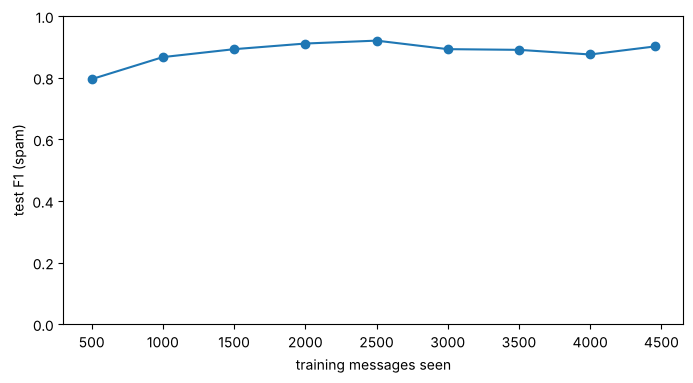

              precision    recall  f1-score   support

           0      0.983     0.987     0.985       966
           1      0.911     0.893     0.902       149

    accuracy                          0.974      1115
   macro avg      0.947     0.940     0.943      1115
weighted avg      0.974     0.974     0.974      1115



In [21]:
plt.figure(figsize=(8, 4))
plt.plot(seen, f1s, marker='o')
plt.xlabel('training messages seen')
plt.ylabel('test F1 (spam)')
plt.ylim(0, 1)
plt.show()
print(classification_report(y_test, stream_clf.predict(X_test_hashed), digits=3))

F1 climbs quickly over the first few batches (0.80 after 500 messages, 0.92 after 2,500) and then wobbles
between about 0.88 and 0.90. With one pass and no learning-rate tuning, each new batch nudges the boundary
around a bit; it doesn't settle the way a multi-epoch `fit` would. Still, 0.90 F1 from a model that never held
more than 500 messages at a time and has no vocabulary is close to the tuned TF-IDF model in notebook 19.

The course colab called `vectorizer.fit_transform` on each half. That works with `HashingVectorizer` because
`fit` does nothing, but with `CountVectorizer` or `TfidfVectorizer` the same code would build a different
vocabulary for each batch and the columns would stop meaning the same thing.

In a real out-of-core setup the batches would come from a file or a database cursor rather than slicing an
array that's already in memory. The scikit-learn gallery has a full version: *Out-of-core classification of
text documents* (Reuters news, streamed from disk).

## Which estimators have partial_fit?

The course list (`MultinomialNB`, `BernoulliNB`, `SGDClassifier`, `Perceptron`, `SGDRegressor`,
`MiniBatchKMeans`) is a subset. Asking scikit-learn directly:

In [22]:
from sklearn.utils import all_estimators

[name for name, cls in all_estimators() if hasattr(cls, 'partial_fit')]

['BernoulliNB',
 'BernoulliRBM',
 'Birch',
 'CategoricalNB',
 'ComplementNB',
 'GaussianNB',
 'HashingVectorizer',
 'IncrementalPCA',
 'LatentDirichletAllocation',
 'MLPClassifier',
 'MLPRegressor',
 'MaxAbsScaler',
 'MinMaxScaler',
 'MiniBatchDictionaryLearning',
 'MiniBatchKMeans',
 'MiniBatchNMF',
 'MultiOutputClassifier',
 'MultiOutputRegressor',
 'MultinomialNB',
 'OneVsOneClassifier',
 'OneVsRestClassifier',
 'PassiveAggressiveClassifier',
 'PassiveAggressiveRegressor',
 'Perceptron',
 'SGDClassifier',
 'SGDOneClassSVM',
 'SGDRegressor',
 'SelectFromModel',
 'StandardScaler']

Grouped:

| | estimators |
|---|---|
| classification | `SGDClassifier`, `Perceptron`, `MultinomialNB`, `BernoulliNB`, `GaussianNB`, `ComplementNB`, `CategoricalNB`, `MLPClassifier` |
| regression | `SGDRegressor`, `MLPRegressor` |
| clustering | `MiniBatchKMeans`, `Birch` |
| decomposition | `IncrementalPCA`, `MiniBatchDictionaryLearning`, `MiniBatchNMF`, `LatentDirichletAllocation` |
| preprocessing | `StandardScaler`, `MinMaxScaler`, `MaxAbsScaler`, `HashingVectorizer` (stateless) |
| other | `SGDOneClassSVM` (outlier detection), `BernoulliRBM`, `SelectFromModel` |
| wrappers | `OneVsRestClassifier`, `OneVsOneClassifier`, `MultiOutputClassifier`, `MultiOutputRegressor`, if the wrapped model has it |

`PassiveAggressiveClassifier` / `Regressor` are deprecated since 1.8; the same thing is now an
`SGDClassifier` / `SGDRegressor` option.

## Summary

* `partial_fit` updates a model with one batch; for classifiers, pass `classes` on the first call
* one call = one pass over that batch. To match `fit()`, go over the data several times (and shuffle if you
  can)
* `pd.read_csv(..., chunksize=n)` reads a big file a piece at a time; watch out for `header`
* preprocessing has to be incremental too: `StandardScaler.partial_fit`, `HashingVectorizer`
* `HashingVectorizer` gives a fixed number of columns with no vocabulary to store, at the cost of
  collisions and not being able to see which word is which